In [1]:
import torch
import matplotlib.pyplot as plt
import math

from renderer import project_gaussians, tile_gaussians,rasterize_tile, rasterize_tile_fast
from utils import ellipse_ndim, plot_tile_map

from matplotlib.patches import Polygon
from tqdm import tqdm

### Data

In [2]:
N = 100

mu = (torch.rand((N,3)) - 0.5) * 4.
scale = torch.rand((N,3)) * 0.2
quat = torch.rand((N, 4))
col = torch.rand((N, 3))
opc = torch.rand((N,))

In [3]:
mu.requires_grad = True
scale.requires_grad = True
quat.requires_grad = True
col.requires_grad = True
opc.requires_grad = True

### Projection

In [4]:
# Output Image Width and Height
W = 1800
H = 1000 

In [5]:
fov_x = math.pi / 2.0 # Angle of the camera frustum 90°
focal = 0.5 * float(W) / math.tan(0.5 * fov_x) # Distance to Image Plane

viewmat = torch.eye(4)
viewmat[:3,3] = torch.tensor([0,0,-4])

In [6]:
(
    mu_,
    cov_,
    z
) = project_gaussians(
    means3d=mu,
    scales=scale,
    quats=quat,
    colors=col,
    viewmat=viewmat,
    fx=focal,
    fy=focal,
    cx=W/2,
    cy=H/2,
    img_height=H,
    img_width=W
)

### Rendering

In [7]:
tile_size = 40

In [8]:
tile_map = tile_gaussians(mu_, cov_, tile_size, H, W)

In [9]:
tile_map

[[[],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [74],
  [74, 98],
  [74, 94, 98],
  [63, 74, 94, 98],
  [63, 74, 92, 94, 98],
  [63, 74, 76, 92, 94, 98],
  [63, 74, 76, 92, 94, 98],
  [63, 74, 76, 92, 94, 98],
  [63, 74, 76, 92, 94, 98],
  [63, 74, 76, 88, 92, 94, 98],
  [63, 76, 88, 92, 94, 98],
  [63, 76, 88, 92, 94, 98],
  [63, 76, 78, 88, 92, 94, 98],
  [63, 64, 76, 78, 88, 92, 94, 98],
  [63, 64, 76, 78, 88, 92, 94, 98],
  [63, 64, 76, 78, 88, 92, 94],
  [63, 76, 78, 88, 92, 94],
  [63, 76, 78, 88, 92, 94],
  [63, 76, 78, 88, 92, 94],
  [76, 88, 92, 94],
  [88, 92, 94],
  [88, 92, 94],
  [88, 92, 94],
  [88, 92, 94],
  [92, 94]],
 [[],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [33],
  [33, 74],
  [33, 44, 74, 98],
  [33, 44, 74, 94, 98],
  [29, 33, 44, 63, 74, 94, 98],
  [29, 33, 44, 63, 74, 92, 94, 98],
  [29, 33, 44, 63, 74, 76, 92, 94, 98

In [10]:
out_img = torch.zeros(H, W, 3)
for y in tqdm(range(len(tile_map))):
    for x in range(len(tile_map[0])):
        if tile_map[y][x]:
            rasterize_tile_fast(
                xys=mu_, covs=cov_, colors=col, opacity=opc,
                x_coord=x, y_coord=y, tile_size=tile_size,
                out_img=out_img,
                tile_map=tile_map
            )

  0%|          | 0/25 [00:00<?, ?it/s]/home/yasin/anaconda3/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 25/25 [00:04<00:00,  5.60it/s]


In [11]:
loss = out_img.mean()

In [12]:
loss.backward()

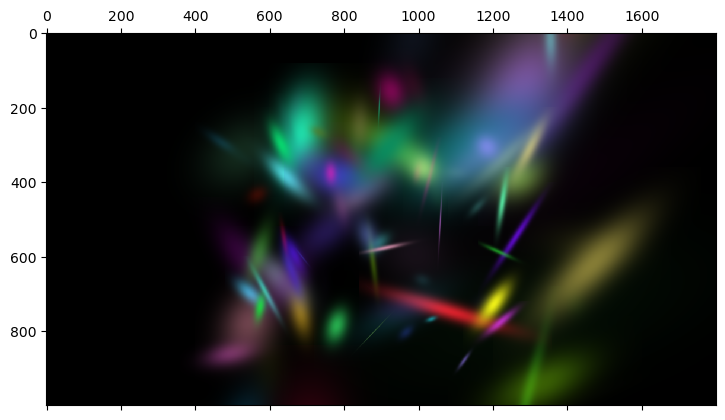

In [13]:
plt.matshow(out_img.detach())